# Step 6: results

Model comparison, the seen/unseen topic breakdown, layer/head correlation heatmaps, L1
coefficients, and grouped permutation importance.

The attention features follow Lookback Lens (Chuang et al., 2024): each group's attention is
divided by the number of tokens in the group, giving a per-token **density** that does not move
with prompt or answer length. See *How this differs from Chuang et al.* in the README for where
this pipeline departs from theirs.

| Model | Blocks | What it is |
|---|---|---|
| `prob` | `prob` | the token-probability baseline (no attention at all) |
| `ll_lookback` | `ll_lookback` | Chuang et al.'s two-group ratio per (layer, head) - 336 features |
| `prob_ll_lookback` | `prob` + `ll_lookback` | what their ratio adds to probability |
| `dens_split` | `dens_split` | the same densities kept split by token type - 1344 features |
| `prob_dens_split` | `prob` + `dens_split` | what the split densities add to probability |

Everything is on the **test** split; run steps 01-05 first.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

sys.path.append(str(Path("..").resolve()))
import aws_config as cfg

CATS = ["context", "question", "special", "instruct", "output"]   # dens_* has all five
CATS4 = ["context", "question", "special", "instruct"]            # output is the dropped reference
PROB_FEATS = ["normalized_score", "prod_score", "min_score", "std_logp", "len_output"]

# The Lookback-Lens-normalized models, in reporting order. Labels come from cfg so this notebook
# and step 05 cannot drift apart.
LL_MODELS = ["prob", "ll_lookback", "prob_ll_lookback", "dens_split", "prob_dens_split"]
LABELS = {k: cfg.MODEL_CONFIGS[k][1] for k in LL_MODELS}

plt.rcParams["figure.dpi"] = 110

## 1. Load predictions, labels, and the per-sample density profile

Each model's `pred`, the `is_correct` label, and two per-sample attention summaries averaged over
all 24 x 14 heads: the five normalized densities `dens_{cat}`, and `ll_lookback` itself.

A model whose results parquet is missing is reported and skipped rather than raising - step 05
writes one per model in `cfg.MODEL_CONFIGS`, so a stale run shows up here as a missing model
instead of a traceback.

In [2]:
labels = (pd.read_parquet(cfg.verification_uri("test")).drop_duplicates("id")
          .set_index("id")["is_correct"].astype(int))
attn = pd.read_parquet(cfg.attention_features_uri("test")).drop_duplicates("id").set_index("id")

def head_mean(prefix):
    """Mean of one feature family over every (layer, head) cell -> one column per sample."""
    cols = [c for c in attn.columns if c.startswith(prefix)]
    assert cols, f"no columns start with {prefix!r} - re-run step 03 to emit the density features"
    return attn[cols].mean(axis=1)

agg = pd.DataFrame({f"dens_{c}": head_mean(f"dens_{c}_head_") for c in CATS})
agg["ll_lookback"] = head_mean("ll_lookback_head_")

df = agg.join(labels, how="inner")

MODELS = []
for name in LL_MODELS:
    try:
        pred = (pd.read_parquet(cfg.results_uri(f"test_{name}.parquet"))
                .drop_duplicates("id").set_index("id")["pred"])
    except Exception as e:
        print(f"  no results for {name!r} ({type(e).__name__}) - re-run step 05")
        continue
    df[name] = pred
    MODELS.append(name)

try:
    raw = pd.read_parquet(cfg.raw_uri("test"))[["id", "title"]].drop_duplicates("id").set_index("id")
    df = df.join(raw, how="left")
except Exception:
    pass

df = df.dropna(subset=["is_correct"] + MODELS)
y = df["is_correct"].values
print(f"N={len(df)}  base rate P(correct)={y.mean():.3f}  models={MODELS}")
df.head(3)

N=1056  base rate P(correct)=0.810  models=['prob', 'll_lookback', 'prob_ll_lookback', 'dens_split', 'prob_dens_split']


,dens_context,dens_question,dens_special,dens_instruct,dens_output,ll_lookback,is_correct,prob,prob_ll_lookback,dens_split,prob_dens_split,title
id,,,,,,,,,,,,
56d0d6db17492d1400aab664,0.031413,0.168193,0.426550,0.042478,0.331366,0.558941,0,0.403503,0.432740,0.676837,0.512935,Buddhism
56d1be69e7d4791d00902101,0.020592,0.116606,0.430941,0.048689,0.383173,0.355564,1,0.557302,0.467668,0.432281,0.485694,Buddhism
56d0f9af17492d1400aab6b8,0.071844,0.106332,0.426885,0.036786,0.358153,0.449622,1,0.460479,0.438224,0.532246,0.541408,Buddhism


## 2. How the models compare

Useful contrasts: `prob_ll_lookback - prob` (does the paper's ratio add signal over
probabilities?), `prob_dens_split - prob_ll_lookback` (does splitting the density by token type
beat their aggregate two-group ratio?), and `ll_lookback` / `dens_split` vs `prob` (can the
density features alone rival probability-based confidence?).

The AUPRC floor is the base rate printed above, so AUPRC separates the models less than ROC-AUC
does. Brier and ECE are calibration, where lower is better.

In [3]:
def ece(p, yy, bins=10):
    b = (p * bins).clip(0, bins - 1).astype(int)
    g = pd.DataFrame({"p": p, "y": yy}).groupby(b)
    return ((g.p.mean() - g.y.mean()).abs() * g.size()).sum() / len(yy)

rows = []
for name in MODELS:
    p = df[name].values
    rows.append([LABELS[name], roc_auc_score(y, p), average_precision_score(y, p),
                 brier_score_loss(y, p), ece(p, y)])
comp = pd.DataFrame(rows, columns=["model", "rocauc", "auprc", "brier", "ece"]).set_index("model")
comp.round(4)

,rocauc,auprc,brier,ece
model,,,,
Pure probability,0.7166,0.9089,0.2270,0.2935
Lookback Lens ratio only,0.7183,0.9145,0.2244,0.2873
Probability + Lookback Lens ratio,0.7491,0.9244,0.2155,0.2821
Attention densities only (split),0.7542,0.9237,0.2066,0.2678
Probability + attention densities (split),0.7895,0.9400,0.1927,0.2534


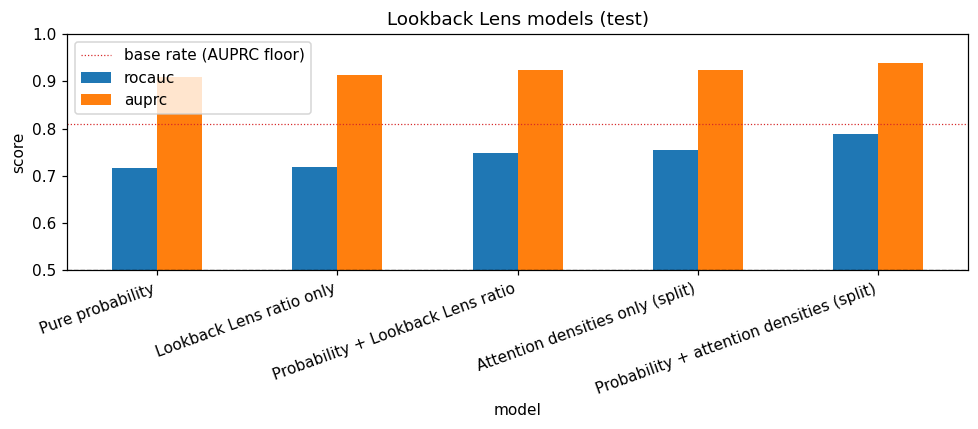

In [4]:
ax = comp[["rocauc", "auprc"]].plot.bar(figsize=(9, 4))
ax.set_ylim(0.5, 1.0)
ax.axhline(y.mean(), color="tab:red", lw=0.8, ls=":", label="base rate (AUPRC floor)")
ax.axhline(0.5, color="k", lw=0.8, ls="--")
ax.set_ylabel("score"); ax.set_title("Lookback Lens models (test)")
plt.xticks(rotation=20, ha="right"); plt.legend(); plt.tight_layout(); plt.show()

## 3. Seen vs unseen topics

Test questions split by whether their Wikipedia **title** also appears in the training split
(*seen* = the topic was trained on and only the questions are held out; *unseen* = the topic never
appeared). Unseen is the honest out-of-distribution check - a confidence model that only works on
familiar topics is not much use.

In [5]:
assert "title" in df.columns, "raw test parquet with `title` did not load in section 1"
train_titles = set(pd.read_parquet(cfg.raw_uri("train"))["title"].unique())
grp = np.where(df["title"].isin(train_titles).values, "seen", "unseen")

rows = []
for g in ["seen", "unseen"]:
    m = grp == g
    yg = y[m]
    if m.sum() == 0 or yg.min() == yg.max():
        print(f"skipping {g}: n={m.sum()}, single-class={yg.min() == yg.max()}")
        continue
    for name in MODELS:
        p = df.loc[m, name].values
        rows.append([g, LABELS[name], int(m.sum()), yg.mean(), roc_auc_score(yg, p),
                     average_precision_score(yg, p), brier_score_loss(yg, p), ece(p, yg)])

su = pd.DataFrame(rows, columns=["group", "model", "n", "base_rate",
                                 "rocauc", "auprc", "brier", "ece"])
print(su.groupby("group")[["n", "base_rate"]].first().round(3))   # cohort size + P(correct)

comp_su = (su.pivot(index="model", columns="group", values=["rocauc", "auprc", "brier", "ece"])
             .reindex([LABELS[k] for k in MODELS]))
comp_su[("rocauc", "delta")] = comp_su[("rocauc", "unseen")] - comp_su[("rocauc", "seen")]
comp_su.round(4)

          n  base_rate
group                 
seen    306      0.814
unseen  750      0.808


rocauc           auprc          \
group                                        seen  unseen    seen  unseen   
model                                                                       
Pure probability                           0.7844  0.6887  0.9376  0.8962   
Lookback Lens ratio only                   0.7678  0.6987  0.9395  0.9039   
Probability + Lookback Lens ratio          0.8289  0.7160  0.9565  0.9107   
Attention densities only (split)           0.7787  0.7446  0.9384  0.9178   
Probability + attention densities (split)  0.8542  0.7644  0.9620  0.9316   

                                            brier             ece          \
group                                        seen  unseen    seen  unseen   
model                                                                       
Pure probability                           0.2062  0.2355  0.2821  0.2985   
Lookback Lens ratio only                   0.2141  0.2287  0.2855  0.2886   
Probability + Lookback Lens ratio          0.1963  0.2233  0.2780  0.2838   
Attention densities only (split)           0.1999  0.2093  0.2670  0.2681   
Probability + attention densities (split)  0.1831  0.1966  0.2656  0.2484   

                                           rocauc  
group                                       delta  
model                                              
Pure probability                          -0.0957  
Lookback Lens ratio only                  -0.0692  
Probability + Lookback Lens ratio         -0.1129  
Attention densities only (split)          -0.0341  
Probability + attention densities (split) -0.0897

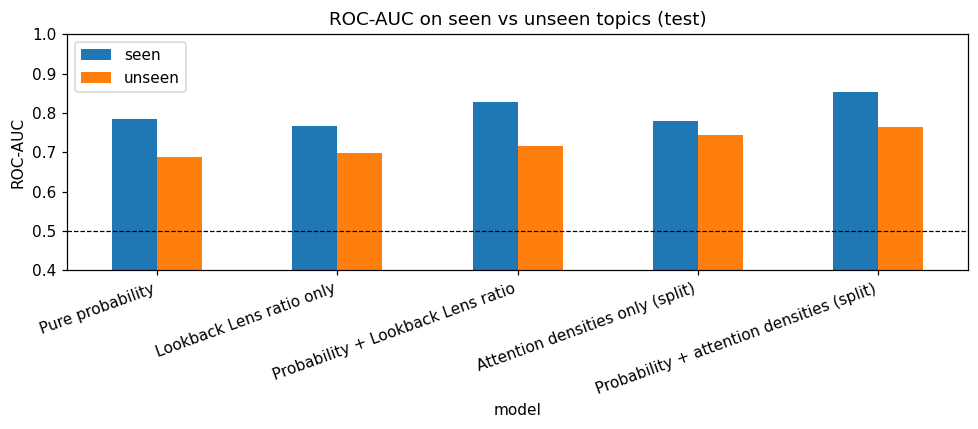

In [6]:
piv = su.pivot(index="model", columns="group", values="rocauc").reindex([LABELS[k] for k in MODELS])
ax = piv.plot.bar(figsize=(9, 4), color=["tab:blue", "tab:orange"])
ax.set_ylim(0.4, 1.0)
ax.axhline(0.5, color="k", lw=0.8, ls="--")
ax.set_ylabel("ROC-AUC"); ax.set_title("ROC-AUC on seen vs unseen topics (test)")
plt.xticks(rotation=20, ha="right"); plt.legend(title=""); plt.tight_layout(); plt.show()

## 4. Where in the network does the signal live? (layer x head)

Point-biserial correlation between each `(layer, head)` feature and correctness. Warm = a head
whose attention there predicts a **correct** answer; cool = predicts a **wrong** one.

`ll_lookback` first (the paper's own statistic: the prompt against the model's own output, per
token), then the five densities. Because the densities are renormalized to sum to 1 across the
five categories, those panels are compositional - a category can only look predictive relative to
the others.

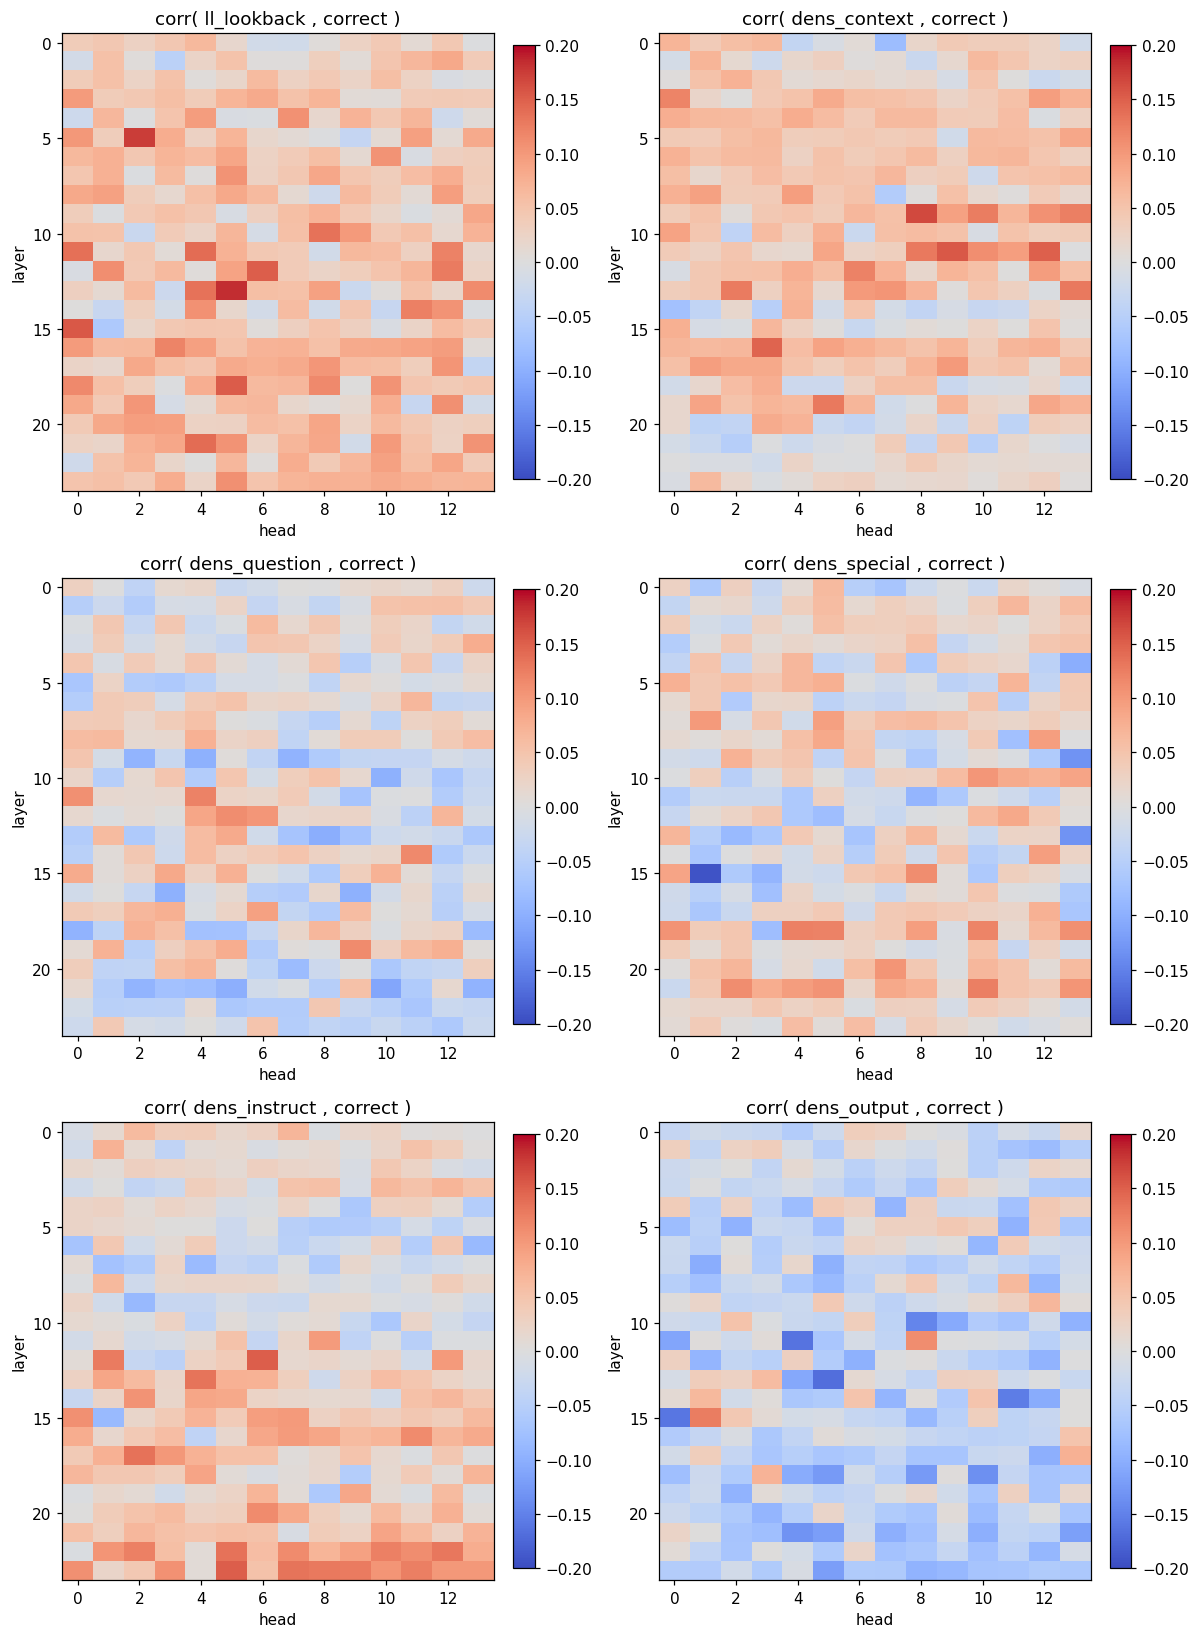

In [7]:
def corr_matrix(prefix, n_layers=24, n_heads=14):
    """Point-biserial corr with correctness for every (layer, head) cell of one feature family.

    `prefix` is the full column name up to `head_`, e.g. "dens_context_" or "ll_lookback_".
    """
    A = attn.loc[df.index]
    cols = {(l, h): f"{prefix}head_{h}_layer_{l}" for l in range(n_layers) for h in range(n_heads)}
    missing = [c for c in cols.values() if c not in A.columns]
    assert not missing, f"{len(missing)} columns missing for prefix {prefix!r}, e.g. {missing[0]}"
    M = np.full((n_layers, n_heads), np.nan)
    for (l, h), c in cols.items():
        if A[c].std() > 1e-9:                    # a constant column has no correlation to report
            M[l, h] = np.corrcoef(A[c].values, y)[0, 1]
    return M

panels = [("ll_lookback", "ll_lookback_")] + [(f"dens_{c}", f"dens_{c}_") for c in CATS]
fig, axes = plt.subplots(3, 2, figsize=(11, 15))
for ax, (title, prefix) in zip(axes.ravel(), panels):
    im = ax.imshow(corr_matrix(prefix), aspect="auto", cmap="coolwarm", vmin=-0.2, vmax=0.2)
    ax.set_title(f"corr( {title} , correct )"); ax.set_xlabel("head"); ax.set_ylabel("layer")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 5. Which features the fitted models keep

Standardized L1-logistic coefficients of the features forward selection actually kept: positive
pushes toward a **correct** answer. Blue = attention density, grey = probability. One panel per
model, then a shared-scale comparison so coefficient magnitudes can be read across models.

This is not Chuang et al.'s fitting procedure - they fit a plain logistic regression on all
L x H ratios, whereas every model here goes through the same L1 + forward-selection pipeline
(cap 25) so that comparisons between blocks are not confounded by the fit. With C = 1e-2 the
penalty is strong, so expect few non-zero coefficients and small magnitudes.

prob                 2
ll_lookback         25
prob_ll_lookback    21
dens_split          25
prob_dens_split     25


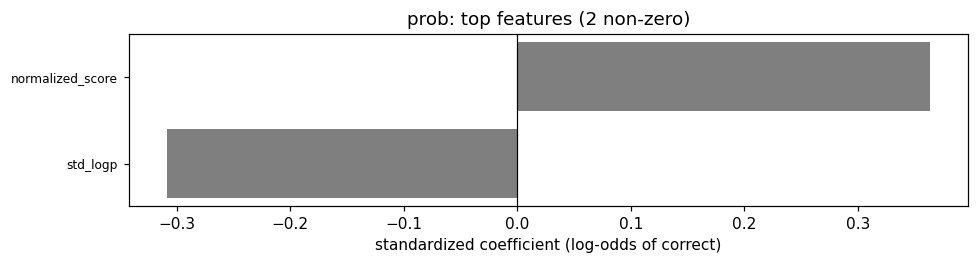

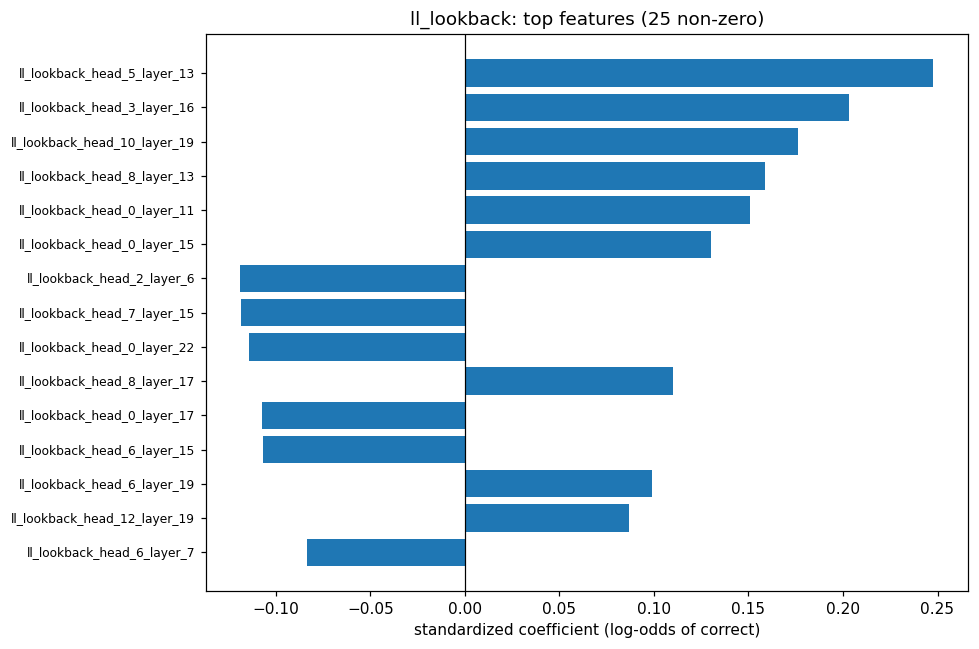

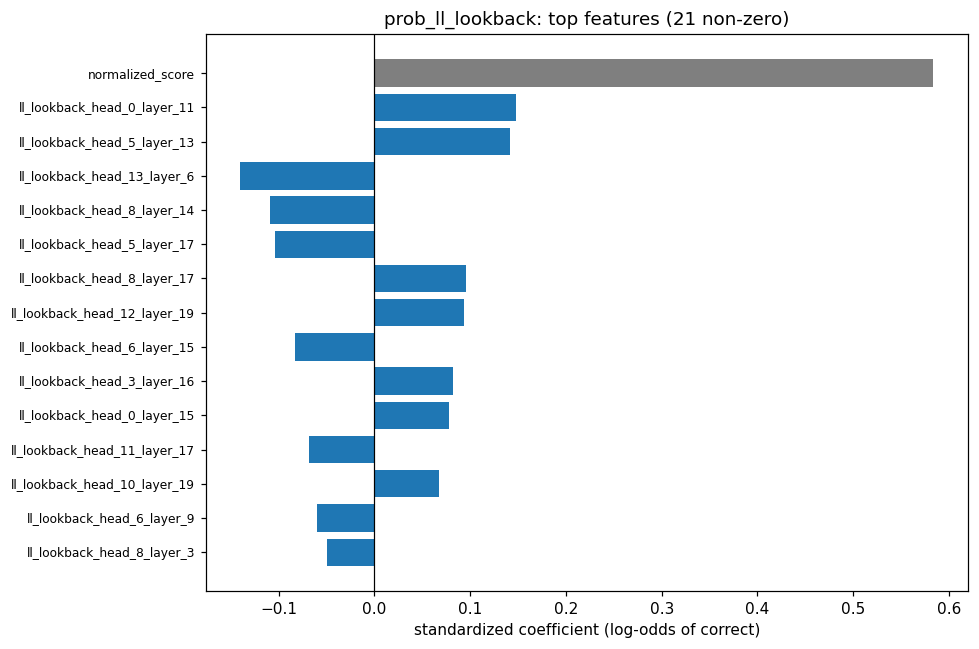

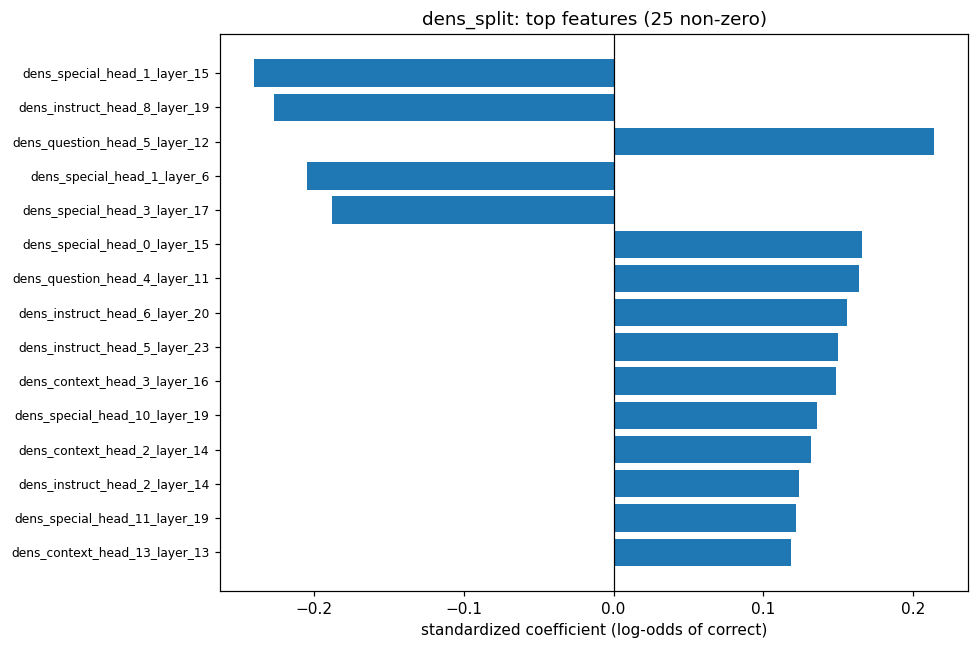

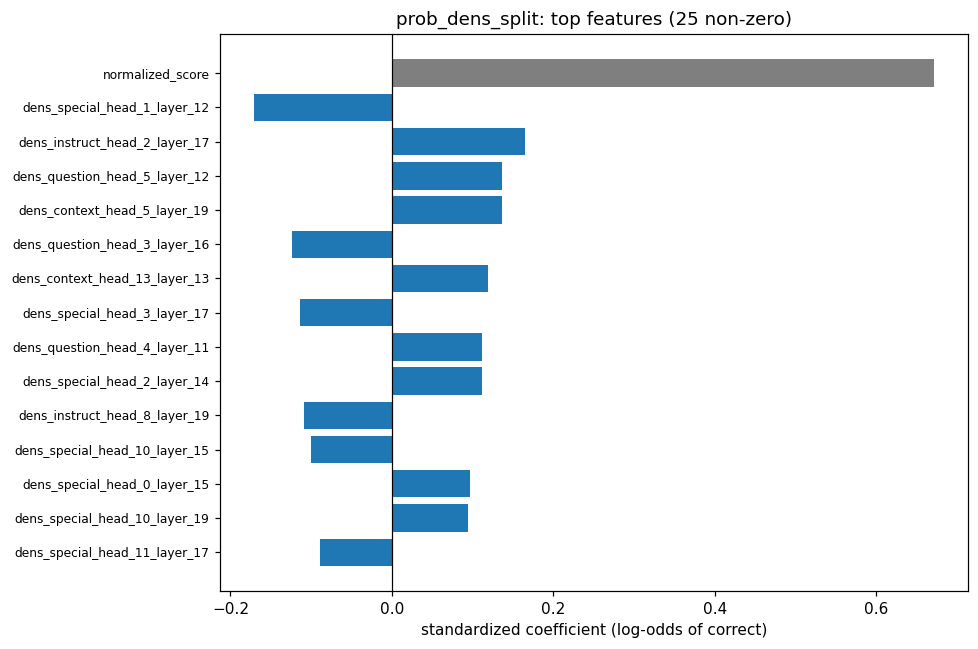

In [8]:
def model_coefs(name):
    """Non-zero standardized coefficients of a fitted model, ordered by |coefficient|."""
    model = cfg.load_joblib(cfg.model_uri(f"{name}.joblib"))
    s = pd.Series(model.named_steps["clf"].coef_[0], index=model.feature_names_in_)
    return s[s.abs() > 1e-8].sort_values(key=abs)

def bar_colors(index):
    return ["tab:gray" if str(i) in PROB_FEATS else "tab:blue" for i in index]

COEFS = {name: model_coefs(name) for name in MODELS}
print(pd.Series({n: len(c) for n, c in COEFS.items()}, name="non-zero coefficients").to_string())

for name, s in COEFS.items():
    s = s.tail(15)
    plt.figure(figsize=(9, max(2.5, 0.4 * len(s))))
    plt.barh(range(len(s)), s.values, color=bar_colors(s.index))
    plt.yticks(range(len(s)), s.index, fontsize=8)
    plt.axvline(0, color="k", lw=0.8)
    plt.xlabel("standardized coefficient (log-odds of correct)")
    plt.title(f"{name}: top features ({len(COEFS[name])} non-zero)")
    plt.tight_layout(); plt.show()

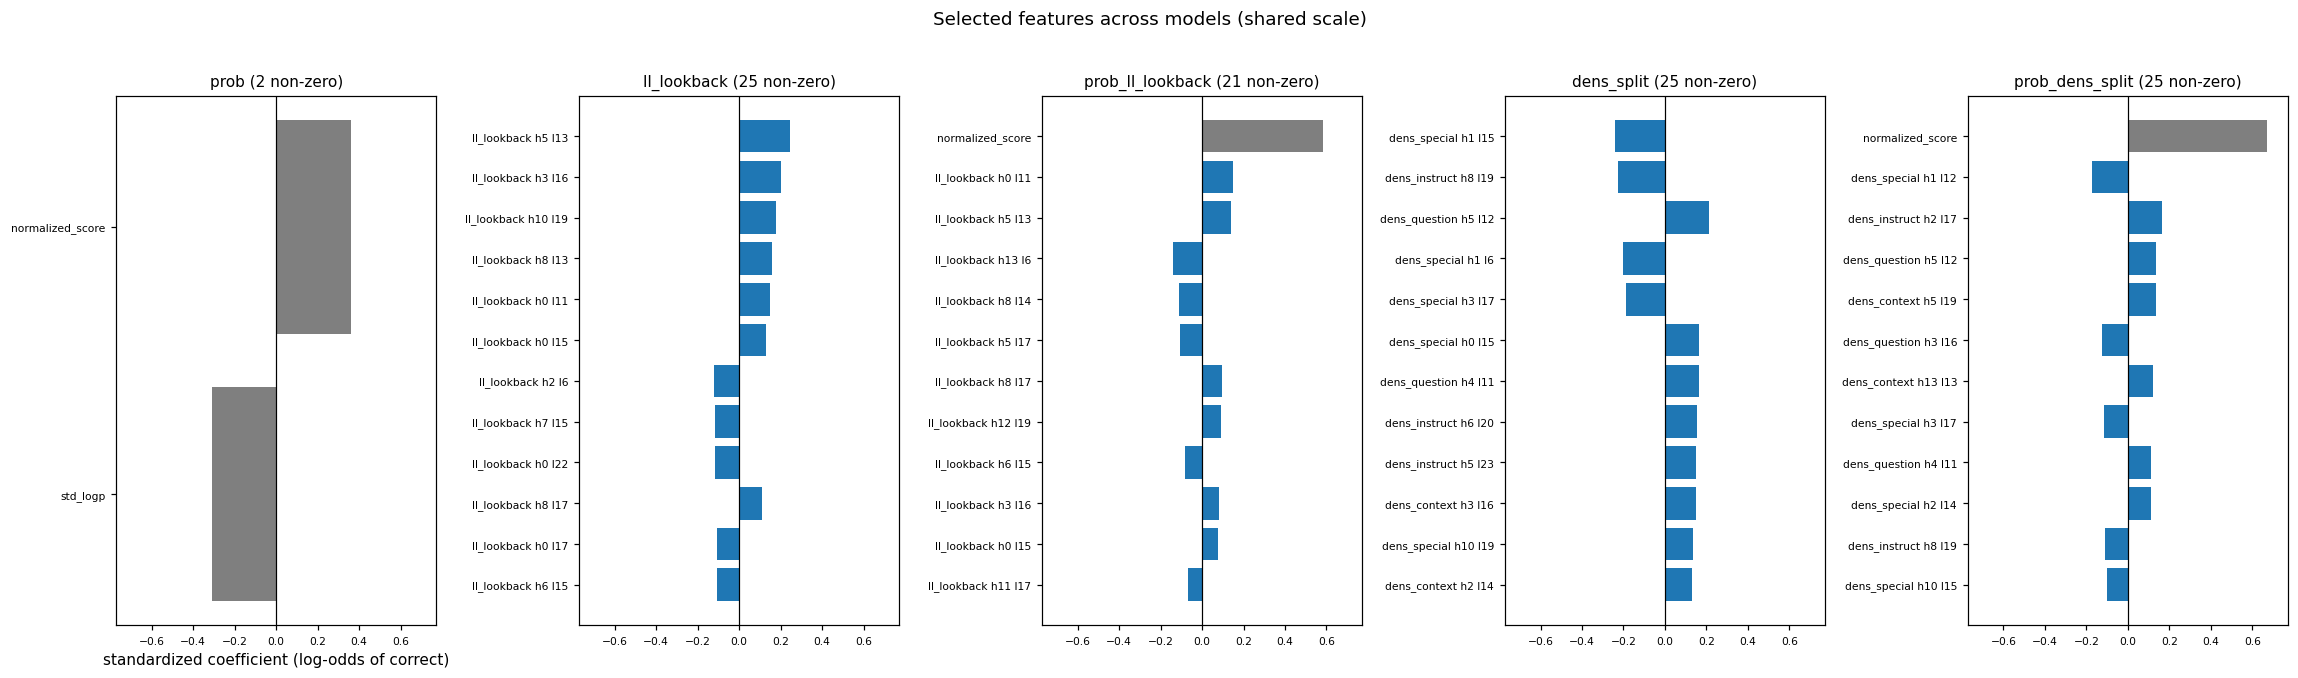

In [9]:
# Same models side by side on one x-scale - a coefficient that looks large in its own
# panel above may be small next to another model's.
lim = max(c.abs().max() for c in COEFS.values()) * 1.15
fig, axes = plt.subplots(1, len(COEFS), figsize=(4.2 * len(COEFS), 6), squeeze=False)
for ax, (name, s) in zip(axes[0], COEFS.items()):
    top = s.tail(12)
    ax.barh(range(len(top)), top.values, color=bar_colors(top.index))
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([str(i).replace("_head_", " h").replace("_layer_", " l")
                        for i in top.index], fontsize=7)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_xlim(-lim, lim)
    ax.set_title(f"{name} ({len(s)} non-zero)", fontsize=10)
    ax.tick_params(axis="x", labelsize=7)
axes[0][0].set_xlabel("standardized coefficient (log-odds of correct)")
fig.suptitle("Selected features across models (shared scale)", y=1.02)
plt.tight_layout(); plt.show()

## 6. Block (grouped) permutation importance

Coefficients cancel when features are collinear, and these densities are collinear by
construction - they are renormalized to sum to 1. Permutation importance sidesteps that: it
measures the **drop in test ROC-AUC when a block of features is shuffled together**, so no
correlated twin is left to cover for the block being permuted.

Set `PERM_MODEL` to any fitted model above. The feature frame is rebuilt exactly as step 05 built
it for these blocks: all `dens_*` except the dropped `dens_output_*` reference category, all
`ll_lookback_*`, and the five probability aggregates.

In [10]:
import re
from collections import defaultdict

PERM_MODEL = "prob_dens_split"      # try "prob_ll_lookback", "dens_split", "ll_lookback"

def build_features(split):
    # The candidate space step 05 trained these models on - dens_output_* is the reference
    # category and is dropped there, so it must be dropped here too.
    a = pd.read_parquet(cfg.attention_features_uri(split)).drop_duplicates("id").set_index("id")
    keep = [c for c in a.columns
            if (c.startswith("dens_") and not c.startswith("dens_output_"))
            or c.startswith("ll_lookback_head_")]
    p = (pd.read_parquet(cfg.probability_features_uri(split))
         .drop_duplicates("id").set_index("id")[PROB_FEATS])
    return a[keep].join(p, how="inner").fillna(0)

def parse(name):
    # feature name -> (block, layer). Probability features -> ('probability', None).
    m = re.match(r"dens_([a-z]+)_head_\d+_layer_(\d+)$", name)
    if m:
        return m.group(1), int(m.group(2))
    m = re.match(r"ll_lookback_head_\d+_layer_(\d+)$", name)
    if m:
        return "ll_lookback", int(m.group(1))
    return "probability", None

def grouped_perm_importance(model, X, yv, groups, n_repeats=20, seed=0):
    # Mean drop in test AUC when each group's columns are jointly row-shuffled.
    rng = np.random.default_rng(seed)
    base = roc_auc_score(yv, model.predict_proba(X)[:, 1])
    imp = {}
    for name, cols in groups.items():
        if not cols:
            continue
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            Xp[cols] = X[cols].values[rng.permutation(len(X))]   # shuffle the whole block together
            drops.append(base - roc_auc_score(yv, model.predict_proba(Xp)[:, 1]))
        imp[name] = float(np.mean(drops))
    return base, imp

model = cfg.load_joblib(cfg.model_uri(f"{PERM_MODEL}.joblib"))
feats = list(model.feature_names_in_)
X = build_features("test").reindex(df.index)[feats].fillna(0)
yv = df.loc[X.index, "is_correct"].values
parsed = {f: parse(f) for f in feats}
print(f"{PERM_MODEL}: {len(feats)} selected features")

prob_dens_split: 25 selected features


In [11]:
by_cat, by_layer, by_lc = defaultdict(list), defaultdict(list), defaultdict(list)
for f in feats:
    cat, layer = parsed[f]
    by_cat[cat].append(f)
    by_layer["prob" if layer is None else layer].append(f)
    if layer is not None:
        by_lc[(cat, layer)].append(f)

base, imp_cat = grouped_perm_importance(model, X, yv, by_cat)
_,   imp_layer = grouped_perm_importance(model, X, yv, by_layer)
_,   imp_lc    = grouped_perm_importance(model, X, yv, by_lc)

print(f"base test AUC = {base:.4f}  (importance = how much AUC drops when a block is shuffled)")
print()
print("by block:")
print(pd.Series(imp_cat).sort_values(ascending=False).round(4))
print()
print("by layer (top 8):")
print(pd.Series(imp_layer).sort_values(ascending=False).head(8).round(4))

base test AUC = 0.7895  (importance = how much AUC drops when a block is shuffled)

by block:
probability    0.1823
question       0.0436
special        0.0386
instruct       0.0281
context        0.0186
dtype: float64

by layer (top 8):
prob    0.1823
17      0.0313
15      0.0231
12      0.0210
19      0.0182
16      0.0150
14      0.0131
11      0.0111
dtype: float64


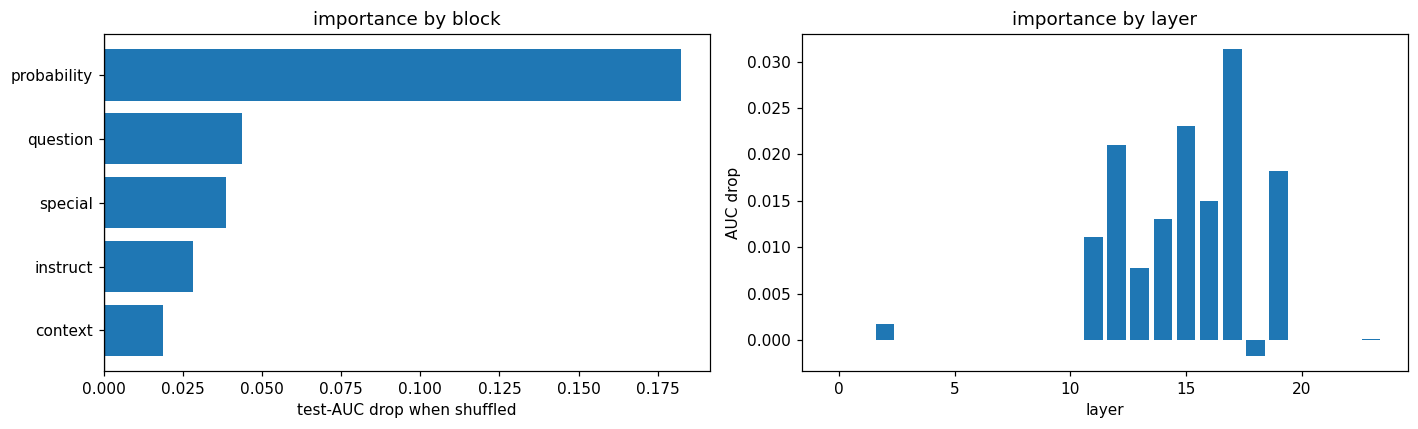

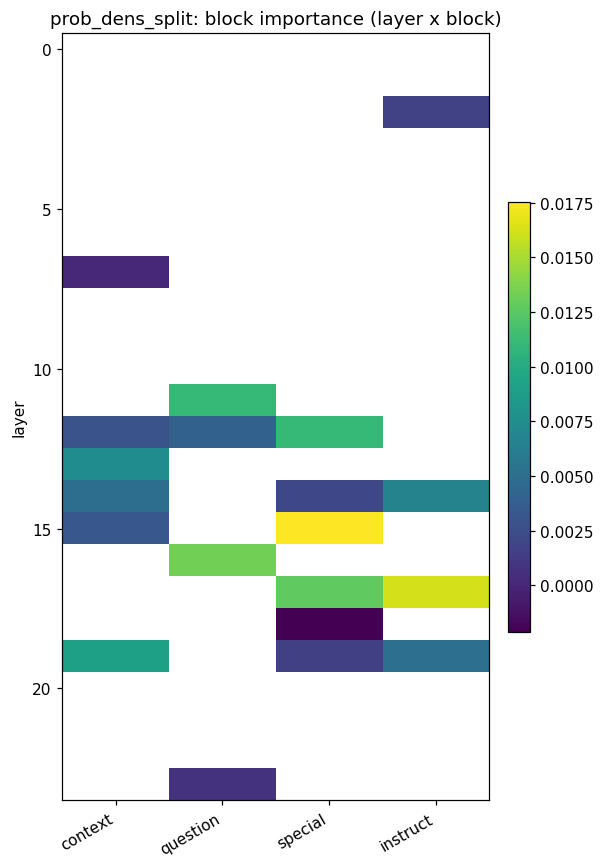

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

s = pd.Series(imp_cat).sort_values()
ax[0].barh(range(len(s)), s.values, color="tab:blue")
ax[0].set_yticks(range(len(s))); ax[0].set_yticklabels(s.index)
ax[0].axvline(0, color="k", lw=0.8)
ax[0].set_title("importance by block"); ax[0].set_xlabel("test-AUC drop when shuffled")

ly = pd.Series({k: v for k, v in imp_layer.items() if k != "prob"}).reindex(range(24)).fillna(0)
ax[1].bar(range(24), ly.values, color="tab:blue")
ax[1].set_title("importance by layer"); ax[1].set_xlabel("layer"); ax[1].set_ylabel("AUC drop")
plt.tight_layout(); plt.show()

blocks = [b for b in CATS4 + ["ll_lookback"] if any(c == b for c, _ in imp_lc)]
M = np.full((24, len(blocks)), np.nan)
for (cat, layer), v in imp_lc.items():
    if cat in blocks:
        M[layer, blocks.index(cat)] = v
fig, ax = plt.subplots(figsize=(max(4, 1.4 * len(blocks)), 8))
im = ax.imshow(M, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(blocks))); ax.set_xticklabels(blocks, rotation=30, ha="right")
ax.set_ylabel("layer"); ax.set_title(f"{PERM_MODEL}: block importance (layer x block)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()